 # Problem 
 The goal is to predict whether a loan application should be approved based on applicant financial and demographic information.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [3]:
df = pd.read_csv('loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [26]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


(614, 13)

In [17]:
df.isnull().mean()*100

Loan_ID              0.000000
Gender               0.000000
Married              0.488599
Dependents           0.000000
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       0.000000
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

<Axes: ylabel='Density'>

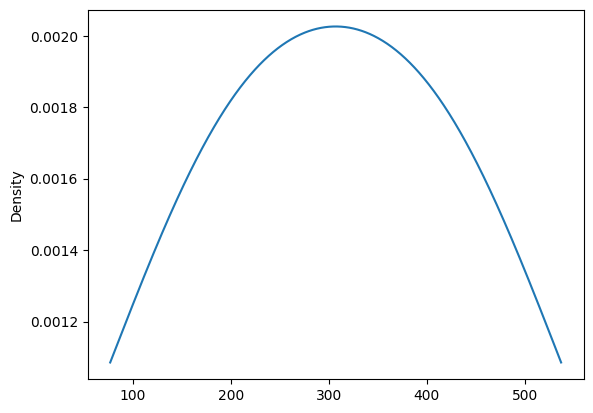

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111)
df['Loan_Status'].value_counts().plot(kind='kde',ax=ax)

In [15]:
# fill categories columns with mode

df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0],inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)

In [18]:
# median 
df['LoanAmount'].fillna(df['LoanAmount'].median(),inplace=True)

In [21]:
# Check Target Variable Distribution

df['Loan_Status'].value_counts()
# or
df['Loan_Status'].value_counts(normalize=True)*100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

<Axes: xlabel='Loan_Status', ylabel='count'>

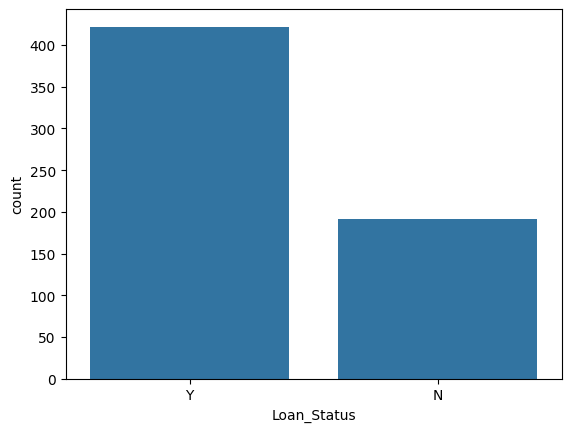

In [28]:
# Exploratory Data Analysis (EDA)
# pd.crosstab(df['Gender'],df['Loan_Status'])

# loan status distribution
sns.countplot(x='Loan_Status',data=df)

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

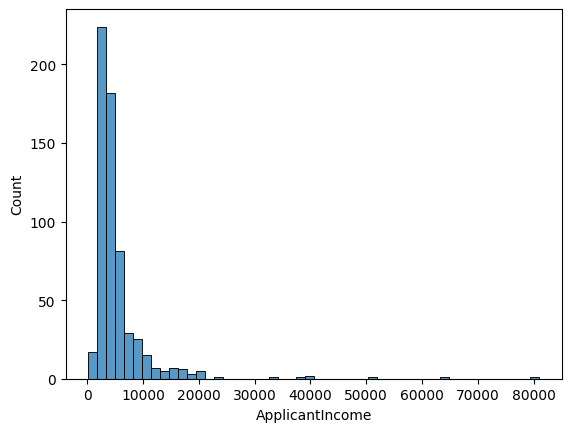

In [29]:
sns.histplot(df['ApplicantIncome'])

<Axes: xlabel='Credit_History', ylabel='count'>

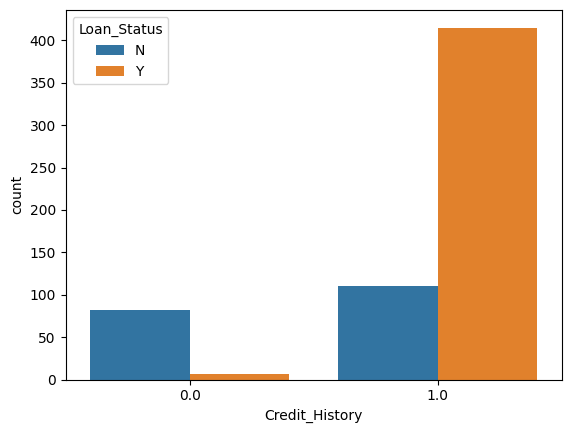

In [30]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)

In [31]:
# Create useful features.

df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [52]:
#Convert Categorical Data to Numbers = Machine learning models cannot understand text.

le = LabelEncoder()

cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [53]:
df.head(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0


In [54]:
X = df.drop(columns=['Loan_Status','Loan_ID'])
y = df['Loan_Status']

In [55]:
# train - test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
TotalIncome          float64
dtype: object

In [69]:
# Train model

model = LogisticRegression()
model.fit(X_train,y_train)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [77]:
Y_pred = model.predict(X_test)
accuracy_score(y_test,Y_pred)
# confusion_matrix(y_test,Y_pred)

0.7886178861788617

<Axes: >

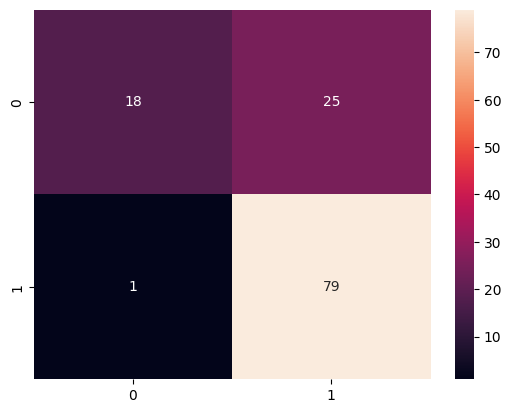

In [78]:
# Visual version of Confusion matrix
sns.heatmap(confusion_matrix(y_test,Y_pred),annot=True,fmt='d')

In [72]:
# Try Another Model
de = DecisionTreeClassifier()
de.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [73]:
Y_pred = de.predict(X_test)
accuracy_score(y_test,Y_pred)

0.6666666666666666

In [75]:
# use Randomforest model and compare with other model
from sklearn.ensemble import RandomForestClassifier

In [76]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
accuracy_score(y_test,y_pred_rf)

0.7560975609756098

In [79]:
# it show which features matter most.
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Credit_History       0.252719
TotalIncome          0.167214
LoanAmount           0.146852
ApplicantIncome      0.144432
CoapplicantIncome    0.086554
Loan_Amount_Term     0.046600
Property_Area        0.042110
Dependents           0.038128
Married              0.021626
Education            0.020130
Gender               0.018549
Self_Employed        0.015085
dtype: float64